Saving Brazilian E-Commerce Dataset.zip to Brazilian E-Commerce Dataset.zip
olist_customers_dataset.csv
Shape: (99441, 5)
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset.csv
Shape: (1000163, 5)
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_order_items_dataset.csv
Shape: (112650, 7)
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset.csv
Shape: (103886, 5)
Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset.csv
Shape: (99224, 7)
Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_orders_dataset.csv
Shape: (99441, 8)
Columns:
['order_id', 'customer

## Business Understanding

### 1.1 Business Context

### 1.2 Business Problem

### 1.3 Project Objectives

### 1.4 Key Business Questions

## Dataset Understanding

In [4]:
import pandas as pd
import zipfile

from google.colab import files

uploaded = files.upload()

zip_file = zipfile.ZipFile("Brazilian E-Commerce Dataset.zip")

for file in zip_file.namelist():
    df = pd.read_csv(zip_file.open(file))
    print("=" * 60)
    print(file)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print()

Saving Brazilian E-Commerce Dataset.zip to Brazilian E-Commerce Dataset (1).zip
olist_customers_dataset.csv
Shape: (99441, 5)
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset.csv
Shape: (1000163, 5)
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_order_items_dataset.csv
Shape: (112650, 7)
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_order_payments_dataset.csv
Shape: (103886, 5)
Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

olist_order_reviews_dataset.csv
Shape: (99224, 7)
Columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

olist_orders_dataset.csv
Shape: (99441, 8)
Columns:
['order_id', 'cust

## Data Quality Assessment

In [13]:
for file in zip_file.namelist():
    if file.endswith(".csv"):
        df = pd.read_csv(zip_file.open(file))

        print("=" * 60)
        print(file)

        print("\nMissing values:")
        print(df.isnull().sum())

        print("\nDuplicate rows:")
        print(df.duplicated().sum())

        print()


        # Load the relevant datasets

customers = pd.read_csv(zip_file.open("olist_customers_dataset.csv"))
orders = pd.read_csv(zip_file.open("olist_orders_dataset.csv"))
order_items = pd.read_csv(zip_file.open("olist_order_items_dataset.csv"))
payments = pd.read_csv(zip_file.open("olist_order_payments_dataset.csv"))
reviews = pd.read_csv(zip_file.open("olist_order_reviews_dataset.csv"))
products = pd.read_csv(zip_file.open("olist_products_dataset.csv"))
sellers = pd.read_csv(zip_file.open("olist_sellers_dataset.csv"))
geolocation = pd.read_csv(zip_file.open("olist_geolocation_dataset.csv"))
category_translation = pd.read_csv(
    zip_file.open("product_category_name_translation.csv")
)

print("Order Status:")
print(orders["order_status"].value_counts())

print("\nPayment Type:")
print(payments["payment_type"].value_counts())

print("\nReview Scores:")
print(reviews["review_score"].value_counts())

print("\nPrice Summary:")
print(items["price"].describe())

print("\nFreight Value Summary:")
print(items["freight_value"].describe())

olist_customers_dataset.csv

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate rows:
0

olist_geolocation_dataset.csv

Missing values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Duplicate rows:
261831

olist_order_items_dataset.csv

Missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate rows:
0

olist_order_payments_dataset.csv

Missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicate rows:
0

olist_order_reviews_dataset.csv

Missing values:
revie

## Questions
1. Is there anything wrong with the data that could affect our analysis?
2. Are the values themselves valid?

Observations
- No widespread missing data in core transactional tables.
- Missing review comments are acceptable.
- Missing delivery dates have a meaningful reason and should remain missing.
- Geolocation contains repeated records but isn't immediately necessary.
- Categorical values look valid.
- Review scores are valid.
- Prices and freight values contain no immediately impossible values.

## Data Cleaning & Preprocessing

### Question

1. Which data do we actually need for the analysis, and what transformations are necessary before we combine it?
2. For each type of missing value, does the missingness represent a problem, or does it carry meaning?

In [26]:
# Make copies so the original data remains unchanged
orders_clean = orders.copy()
items_clean = items.copy()
payments_clean = payments.copy()
reviews_clean = reviews.copy()
products_clean = products.copy()
customers_clean = customers.copy()
order_items_clean = order_items.copy()


# Convert date columns to datetime
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

items_clean["shipping_limit_date"] = pd.to_datetime(
    items_clean["shipping_limit_date"]
)

reviews_clean["review_creation_date"] = pd.to_datetime(
    reviews_clean["review_creation_date"]
)

reviews_clean["review_answer_timestamp"] = pd.to_datetime(
    reviews_clean["review_answer_timestamp"]
)

orders_clean.dtypes


products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna("Unknown")
)

# products_clean["product_category_name"].value_counts().head()
(products_clean["product_category_name"] == "Unknown").sum()

np.int64(610)

## Data Integration

## Questions
1. How do we connect these separate tables so that we can analyze customer behaviour, orders, products, payments, reviews, etc. together?

In [45]:
# Start with Orders + Customers
# An order tells us what happened, but customers tells us who made the order and their location.

customer_orders = orders_clean.merge(
    customers_clean,
    on="customer_id",
    how="left"
)

# print("Shape:", customer_orders.shape)
customer_orders.head()


customer_order_items = customer_orders.merge(
    order_items_clean,
    on="order_id",
    how="left"
)

# print("Shape:", customer_order_items.shape)

missing_items = customer_order_items["product_id"].isna().sum()

# print("Orders without matching order items:", missing_items)


customer_order_products = customer_order_items.merge(
    products_clean,
    on="product_id",
    how="left"
)

# print("Shape:", customer_order_products.shape)

missing_products = customer_order_products["product_id"].isna().sum()

# print("Rows without a product:", missing_products)

# payments_clean["order_id"].value_counts().head(10)


# print("Unique orders with payments:", payments_clean["order_id"].nunique())
# print("Total payment records:", len(payments_clean))

# Because payment records have a one-to-many relationship with orders, payment-level data will be aggregated to the order level before integration to prevent unnecessary row multiplication.
payment_summary = payments_clean.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_count=("order_id", "count"),
    total_installments=("payment_installments", "sum")
).reset_index()

customer_order_products_payments = customer_order_products.merge(
    payment_summary,
    on="order_id",
    how="left"
)

customer_order_products_payments = customer_order_products.merge(
    payment_summary,
    on="order_id",
    how="left"
)

# Doing the same thing we did with payments
review_summary = reviews_clean.groupby("order_id").agg(
    average_review_score=("review_score", "mean")
).reset_index()


final_dataset = customer_order_products_payments.merge(
    review_summary,
    on="order_id",
    how="left"
)

print(final_dataset.shape)

# print("Shape:", final_dataset.shape)

review_summary["order_id"].value_counts().head(10)
(review_summary["order_id"].value_counts() > 1).sum()



(113425, 30)


np.int64(0)

### Observations

Orders:                    99,441

Order-item records:        112,650

Orders without items:          775

Merged dataset:            113,425

Those 775 orders don't have a matching order_items record.



## Note
The datasets were integrated using their primary keys:

- Customers ↔ Orders via customer_id
- Orders ↔ Order Items via order_id
- Order Items ↔ Products via product_id
- Orders ↔ Payments via order_id
- Orders ↔ Reviews via order_id

Because payments and reviews contained one-to-many relationships with orders, they were aggregated to the order level before integration to avoid row duplication.

The final integrated analytical dataset contained:

113,425 rows
30 columns

## Feature Engineering

## Questions
What new variables can we create that don't already exist in the raw data?

In [53]:
# Feature 1: Delivery Time -> Measures logistics efficiency
final_dataset["delivery_time_days"] = (
    final_dataset["order_delivered_customer_date"]
    - final_dataset["order_purchase_timestamp"]
).dt.days

# Feature 2: Approval Time -> Measures how quickly orders are approved
final_dataset["approval_time_hours"] = (
    final_dataset["order_approved_at"]
    - final_dataset["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# Feature 3: Purchase Year -> Enables yearly trend analysis
final_dataset["purchase_year"] = (
    final_dataset["order_purchase_timestamp"].dt.year
)

# Feature 4: Purchase Month -> Enables seasonality analysis
final_dataset["purchase_month"] = (
    final_dataset["order_purchase_timestamp"].dt.month
)

# Feature 5: Order Value -> Represents total item cost including shipping.
final_dataset["order_value"] = (
    final_dataset["price"]
    + final_dataset["freight_value"]
)






final_dataset["item_value"] = (
    final_dataset["price"] + final_dataset["freight_value"]
)


# final_dataset[
#     [
#         "delivery_time_days",
#         "approval_time_hours",
#         "purchase_year",
#         "purchase_month",
#         "order_value"
#     ]
# ].head()

final_dataset.drop(columns=["order_value"], inplace=True)



# Collapse to one row per order: e.g Give me one row per order, and summarize all its items."
order_level = final_dataset.groupby("order_id").agg(
    customer_unique_id=("customer_unique_id", "first"),
    order_status=("order_status", "first"),
    order_purchase_timestamp=("order_purchase_timestamp", "first"),
    purchase_year=("purchase_year", "first"),
    purchase_month=("purchase_month", "first"),
    delivery_time_days=("delivery_time_days", "first"),
    approval_time_hours=("approval_time_hours", "first"),
    total_payment_value=("total_payment_value", "first"),
    payment_count=("payment_count", "first"),
    total_installments=("total_installments", "first"),
    average_review_score=("average_review_score", "first"),
    total_item_value=("item_value", lambda x: x.sum(min_count=1)),
    total_price=("price", lambda x: x.sum(min_count=1)),
    total_freight=("freight_value", lambda x: x.sum(min_count=1)),
    total_items=("order_item_id", "count"),
    unique_products=("product_id", "nunique"),
    unique_sellers=("seller_id", "nunique")
).reset_index()

# print("Shape:", order_level.shape)
# order_level.head()


# Customer-level features
customer_features = order_level.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spend=("total_item_value", "sum"),
    average_order_value=("total_item_value", "mean"),
    average_review_score=("average_review_score", "mean"),
    average_delivery_time=("delivery_time_days", "mean"),
    total_items_purchased=("total_items", "sum"),
    total_freight=("total_freight", "sum")
).reset_index()

print("Shape:", customer_features.shape)
customer_features.head()


# Next: RFM features
# Before clustering, we should create the classic RFM variables:
# R - Recency: How recently did the customer purchase?
# F - Frequency: How often did they purchase?
# M - Monetary: How much did they spend?


reference_date = order_level["order_purchase_timestamp"].max()

customer_recency = order_level.groupby("customer_unique_id").agg(
    last_purchase_date=("order_purchase_timestamp", "max")
).reset_index()

customer_recency["recency_days"] = (
    reference_date - customer_recency["last_purchase_date"]
).dt.days

customer_features = customer_features.merge(
    customer_recency[["customer_unique_id", "recency_days"]],
    on="customer_unique_id",
    how="left"
)

print("Reference date:", reference_date)
customer_features.head()


Shape: (96096, 8)
Reference date: 2018-10-17 17:30:18


,customer_unique_id,total_orders,total_spend,average_order_value,average_review_score,average_delivery_time,total_items_purchased,total_freight,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,6.0,1,12.00,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,3.0,1,8.29,163
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,25.0,1,17.22,585
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,20.0,1,17.63,369
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,13.0,1,16.89,336


## Exploratory Data Analysis

Questions

1. How did purchasing activity change over time?



/tmp/ipykernel_2047/721420044.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


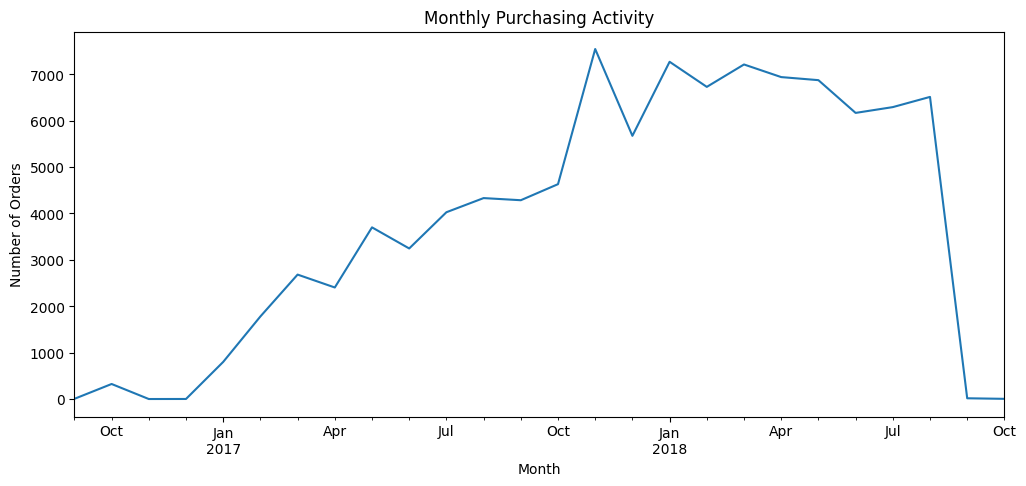

In [80]:
# Count orders by month
monthly_orders = (
    order_level
    .set_index("order_purchase_timestamp")
    .resample("M")
    .size()
)

monthly_orders

import matplotlib.pyplot as plt

monthly_orders.plot(figsize=(12, 5))

plt.title("Monthly Purchasing Activity")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

Monthly purchasing activity increased over the observed period, reaching its highest level around October-January before declining afterward. This indicates that customer purchasing behaviour was not uniform throughout the dataset period and may exhibit seasonal or time-dependent patterns. The concentration of activity toward the end of the observation period should be considered when analysing customer behaviour and purchasing trends.

2. What does the customer spending distribution look like?

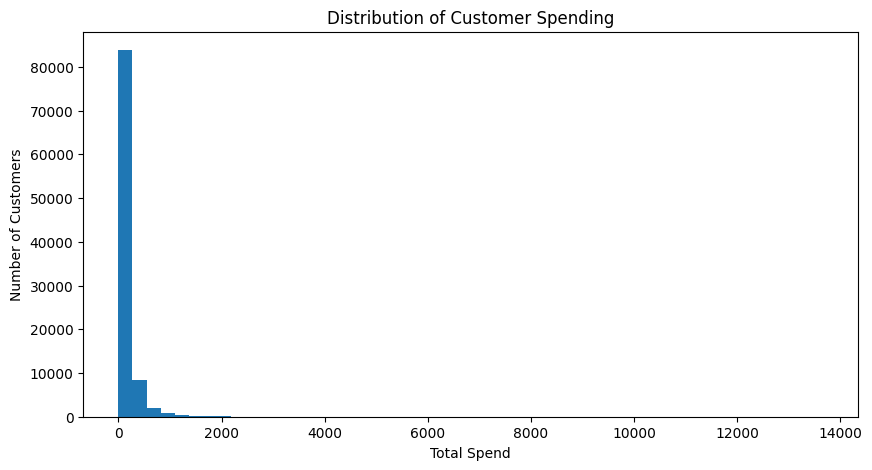

In [82]:
# Examine the distribution of customer spending
customer_features["total_spend"].describe()

import matplotlib.pyplot as plt

customer_features["total_spend"].plot(
    kind="hist",
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()

Customer spending is strongly right-skewed. Most customers have relatively low total spending, while a smaller number of customers have substantially higher spending, creating a long right tail. This indicates that spending is unevenly distributed across customers and supports the use of a logarithmic transformation to reduce the influence of extreme values during clustering.

3. How frequently do customers purchase?


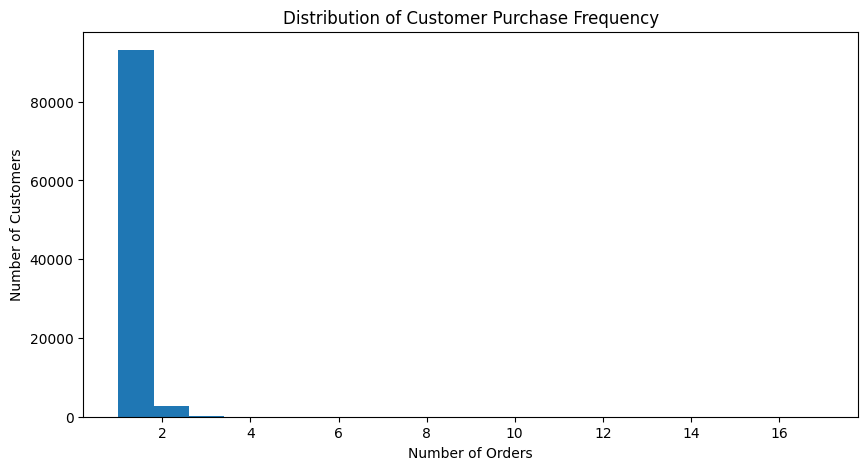

In [84]:
# Examine customer purchase frequency
customer_features["total_orders"].describe()

import matplotlib.pyplot as plt

customer_features["total_orders"].plot(
    kind="hist",
    bins=20,
    figsize=(10, 5)
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

Customer purchase frequency is concentrated at a low number of orders, with most customers making between one and three purchases. The number of customers decreases as purchase frequency increases, with relatively few customers making many orders. This indicates that while repeat purchasing exists, highly frequent purchasing is uncommon within the customer base.

## Unsupervised Learning / Pattern Discovery

In [76]:
customer_features.describe().T
customer_features.isnull().sum()

customer_features[
    customer_features["average_order_value"].isna()
].head()
# customer_features[
#     customer_features["average_order_value"].isna()
# ].shape


# So these aren't customers who somehow have an unknown order value. They're the 775 orders we discovered earlier that had no matching order-item records; 676 of those belong to unique customers
customer_features["average_order_value"] = (
    customer_features["average_order_value"].fillna(0)
)

# print(customer_features.isnull().sum())


customer_features["review_score_missing"] = (
    customer_features["average_review_score"].isna().astype(int)
)

customer_features["delivery_time_missing"] = (
    customer_features["average_delivery_time"].isna().astype(int)
)

customer_features["average_review_score"] = (
    customer_features["average_review_score"]
    .fillna(customer_features["average_review_score"].median())
)

customer_features["average_delivery_time"] = (
    customer_features["average_delivery_time"]
    .fillna(customer_features["average_delivery_time"].median())
)

numeric_features = customer_features.select_dtypes(include="number")

numeric_features.skew().sort_values(ascending=False)

import numpy as np

log_features = [
    "total_orders",
    "total_spend",
    "average_order_value",
    "total_items_purchased",
    "total_freight",
    "average_delivery_time"
]

# Apply log transformation
for col in log_features:
    customer_features[f"log_{col}"] = np.log1p(customer_features[col])

# Check skewness after transformation
log_skewness = customer_features[
    [f"log_{col}" for col in log_features]
].skew().sort_values(ascending=False)

# print(log_skewness)



clustering_features = [
    "log_total_orders",
    "log_total_spend",
    "log_average_order_value",
    "average_review_score",
    "log_average_delivery_time",
    "log_total_items_purchased",
    "log_total_freight",
    "recency_days",
    "review_score_missing",
    "delivery_time_missing"
]

X = customer_features[clustering_features].copy()

# X.head()


# Scaling: It puts each feature onto roughly the same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# X_scaled.head()


# Clustering: How many customer groups should we create?
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluate different numbers of clusters using silhouette score
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    silhouette_scores[k] = score

print(silhouette_scores)





KeyboardInterrupt: 

In [77]:
# Fit the final K-Means model using 5 clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = kmeans.fit_predict(X_scaled)

# Check the number of customers in each cluster
customer_features["cluster"].value_counts().sort_index()

,count
cluster,
0,47156
1,30134
2,15121
3,3009
4,676


In [78]:
# Profile the clusters by looking at their actual behaviour:
cluster_profile = customer_features.groupby("cluster").agg(
    customers=("customer_unique_id", "count"),
    total_orders=("total_orders", "mean"),
    total_spend=("total_spend", "mean"),
    average_order_value=("average_order_value", "mean"),
    average_review_score=("average_review_score", "mean"),
    average_delivery_time=("average_delivery_time", "mean"),
    total_items_purchased=("total_items_purchased", "mean"),
    total_freight=("total_freight", "mean"),
    recency_days=("recency_days", "mean")
).round(2)

cluster_profile

,customers,total_orders,total_spend,average_order_value,average_review_score,average_delivery_time,total_items_purchased,total_freight,recency_days
cluster,,,,,,,,,
0,47156,1.00,73.89,73.89,4.62,9.14,1.02,14.69,284.82
1,30134,1.00,304.03,304.03,4.58,12.75,1.27,34.78,286.27
2,15121,1.00,148.95,148.95,1.57,19.83,1.21,24.04,299.57
3,3009,2.11,314.05,155.64,4.11,11.87,2.60,49.11,268.43
4,676,1.01,0.00,0.00,1.70,10.00,0.00,0.00,377.67


### Observation

1. Cluster Selection: K-Means clustering was evaluated for K values from 2 to 10 using the silhouette score. The highest score was obtained at K=5 (0.236), indicating that the 5-cluster solution provided the best separation among the tested configurations. However, the relatively low score suggests substantial overlap between customer segments.

2. The customer base is dominated by one-time purchasers, but those customers differ substantially in spending and review experience. A smaller group consists of repeat purchasers, while another small group is associated with incomplete order-item records.

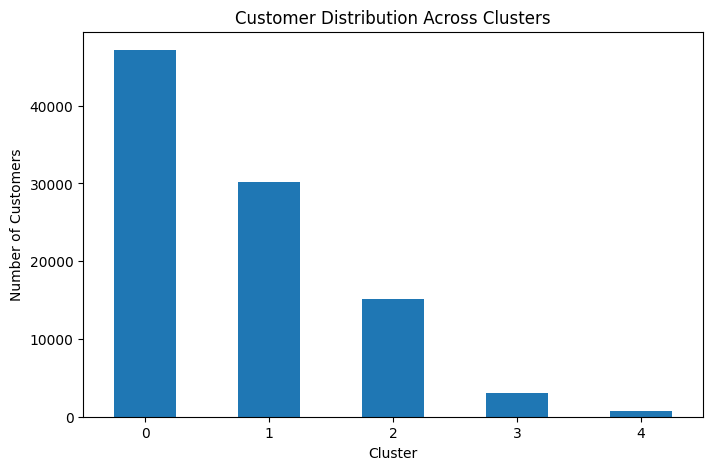

In [85]:
# Visualize the number of customers in each cluster
customer_features["cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

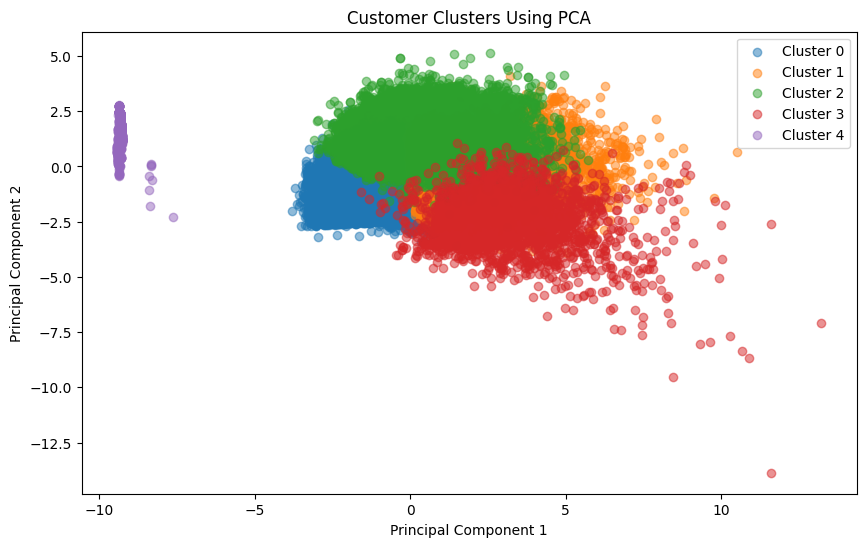

In [88]:
# 2D visualization of the clusters

from sklearn.decomposition import PCA

# Reduce the clustering features to two dimensions
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = customer_features["cluster"].values

# Visualize customer clusters in two dimensions
plt.figure(figsize=(10, 6))

for cluster in sorted(pca_df["cluster"].unique()):
    cluster_data = pca_df[pca_df["cluster"] == cluster]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.title("Customer Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

## Business Interpretation

### **Cluster 0: Low-spending, satisfied customers**

**Data:**
- 47,156 customers
- 1.00 average order
- ~73.89 average spend
- 4.62 average review
- 9.14 days delivery

**Interpretation:**

Cluster 0 represents the largest customer group, consisting primarily of one-time, relatively low-spending customers. Despite their low purchasing frequency and spending, they report high average review scores and relatively short delivery times. This suggests that the group generally has a positive customer experience but has not developed strong repeat-purchase behaviour.

### **Cluster 1: Higher-spending customers**

**Data**
- 30,134 customers
- 1.00 average order
- ~304.03 average spend
- 4.58 review
- 12.75 days delivery

Cluster 1 consists primarily of one-time customers with substantially higher spending than Cluster 0. Their high average review score indicates generally positive experiences. However, the fact that most customers have only one order suggests that higher transaction value does not necessarily translate into repeat purchasing.

### **Cluster 2: Low satisfaction / slower delivery**

**Data**
- 15,121 customers
- 1.00 average order
- ~148.95 spend
- 1.57 review
- 19.83 days delivery

Cluster 2 is characterized by relatively low customer satisfaction and longer delivery times. The average review score of 1.57 is considerably lower than the other major clusters, while the average delivery time is also the highest. This suggests a potential relationship between delivery experience and customer satisfaction that warrants further investigation.


### **Cluster 3: Repeat purchasers**

**Data**
- 3,009 customers
- 2.11 orders
- ~314.05 spend
- 2.60 items
- 4.11 review
- 268 days recency

Cluster 3 represents a smaller group of relatively more engaged customers. These customers have the highest average number of orders and purchase more items than the other major customer groups. Their higher spending and more recent purchasing activity indicate stronger engagement with the platform. However, their average review score is lower than Clusters 0 and 1, indicating that repeat purchasing does not necessarily correspond to the highest satisfaction scores.

### **Cluster 4: Data-quality-related group**
Data
- 676 customers
- ~0 spend
- 0 items
- 0 freight
- 1.70 review
- 377.67 recency

This one needs special treatment:

Cluster 4 is substantially different from the other groups, with zero recorded spending and items purchased. This cluster should not be interpreted as a genuine zero-spending customer segment because earlier data-quality analysis identified 775 orders without matching order-item records, involving 676 unique customers. The characteristics of this cluster therefore appear to be strongly influenced by incomplete order-item information rather than actual purchasing behaviour.


### **Key Business Insight:**
The analysis indicates that the customer base is dominated by one-time purchasers, with meaningful differences in spending and customer experience among these customers. A smaller group of repeat purchasers demonstrates higher purchasing activity and spending, while another group is characterized by particularly low review scores and longer delivery times. These patterns suggest that customer retention, high-value customer engagement, and delivery performance are important areas for further business attention. However, the data-quality-related Cluster 4 should be treated separately when making business decisions.

## Recommendations

**Likely recommendations will include:**

1. Strategies to encourage one-time customers to make repeat purchases.
2. Targeted engagement of higher-spending customers.
3. Investigating delivery performance and customer dissatisfaction for Cluster 2.
4. Using the repeat-purchasing group to understand behaviours associated with retention.
5. Improving data integration/quality so incomplete orders don't form an artificial cluster.

## Challenges, Assumptions & Limitations

1. The dataset contains missing values.
2. Some orders have no matched order-item records.
3. Review records can be missing.
4. K-Means assumes meaningful numerical distance between observations.
5. Customer behaviour is represented using the available historical data.
6. The relatively low silhouette score (~0.236) indicates that the clusters overlap considerably.
7. Cluster labels are arbitrary.
8. PCA visualization is only a 2D representation of a higher-dimensional dataset.
9. The dataset is historical, so patterns may not represent current customer behaviour.
10. The dataset contains only the information available in Olist, limiting some business conclusions.

## Conclusion

## 12. Conclusion

This project used the Olist Brazilian E-Commerce dataset to analyze customer purchasing behaviour through data cleaning, integration, feature engineering, EDA, and unsupervised learning. The analysis identified five customer clusters with differences in spending, purchase frequency, satisfaction, and delivery experience. Overall, most customers were one-time purchasers, while a smaller group showed stronger repeat-purchasing behaviour, demonstrating how unsupervised learning can uncover meaningful customer patterns and support data-driven business decisions.
